# Serial Repetition CRP

> Compute and visualize serial repetition CRP conditioned on correct recall order.

The serial repetition CRP conditions on correctly ordered output up to the point of analysis. It tabulates repetition-index CRPs only for transitions where the recall sequence matches study order, stopping once an out-of-order response occurs.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query string selecting mixed (repeated-item) trials |
| `control_trial_query` | Query string selecting pure (control) trials |
| `control_shuffles` | Number of shuffled control blocks per subject |
| `min_lag` | Minimum spacing between repeated occurrences |
| `max_lag` | Maximum lag to display |
| `size` | Maximum presentations per item |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.serialrepcrp import (
    plot_rep_crp,
    plot_difference_rep_crp,
    plot_first_rep_crp,
    plot_second_rep_crp,
    repcrp,
    tabulate_trial,
    subject_serial_rep_crp,
    test_serial_rep_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = 'data["list_type"] > 2'
control_trial_query = 'data["list_type"] == 1'
control_shuffles = 10
min_lag = 2
max_lag = 3
size = 2

In [4]:
#| code-summary: Load data and build control dataset
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(
    data, mixed_trial_query, control_trial_query, control_shuffles
)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

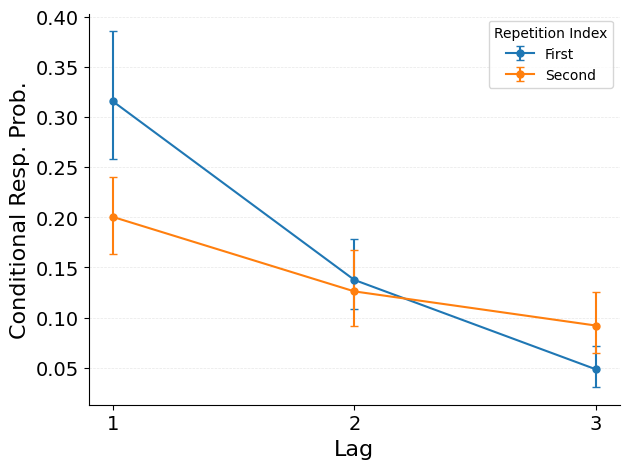

In [5]:
#| code-summary: Plot serial repetition Lag-CRP (observed)
#| label: fig-serialrepcrp
#| fig-cap: "Serial repetition Lag-CRP for each presentation index of repeated items."
plot_rep_crp(
    data,
    trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

---

## Reference

In [6]:
#| echo: false
show_doc(plot_rep_crp)

---

### plot_rep_crp

>      plot_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr
>                    .typing.RecallDataset], trial_masks:Union[Sequence[jaxtypin
>                    g.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial_co
>                    unt']], max_lag:int=3, min_lag:int=2, size:int=2,
>                    repetition_index:Optional[int]=None,
>                    color_cycle:Optional[list[str]]=None,
>                    labels:Optional[Sequence[str]]=None,
>                    contrast_name:Optional[str]=None,
>                    axis:Optional[matplotlib.axes._axes.Axes]=None,
>                    confidence_level:float=0.95)

*Plot serial repetition lag-CRP with CIs.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Datasets containing trial data to plot. |
| trial_masks | Union |  | Masks to filter trials in datasets. |
| max_lag | int | 3 | Maximum lag to display. |
| min_lag | int | 2 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum presentations per item. |
| repetition_index | Optional | None | Plot only this repetition index. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for repetition-index lines. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the serial repetition CRP plot.** |

In [7]:
#| echo: false
show_doc(plot_difference_rep_crp)

---

### plot_difference_rep_crp

>      plot_difference_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallData
>                               set],jaxcmr.typing.RecallDataset], trial_masks:U
>                               nion[Sequence[jaxtyping.Bool[Array,'trial_count'
>                               ]],jaxtyping.Bool[Array,'trial_count']],
>                               max_lag:int=3, min_lag:int=4, size:int=2,
>                               color_cycle:Optional[list[str]]=None,
>                               labels:Optional[Sequence[str]]=None,
>                               contrast_name:Optional[str]=None,
>                               axis:Optional[matplotlib.axes._axes.Axes]=None,
>                               confidence_level:float=0.95)

*Plot first-minus-second serial repetition CRP.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Datasets containing trial data to plot. |
| trial_masks | Union |  | Masks to filter trials in datasets. |
| max_lag | int | 3 | Maximum lag to display. |
| min_lag | int | 4 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum presentations per item. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the difference CRP plot.** |

In [8]:
#| echo: false
show_doc(plot_first_rep_crp)

---

### plot_first_rep_crp

>      plot_first_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],
>                          jaxcmr.typing.RecallDataset], trial_masks:Union[Seque
>                          nce[jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bo
>                          ol[Array,'trial_count']], max_lag:int=3,
>                          min_lag:int=2, size:int=2,
>                          color_cycle:Optional[list[str]]=None,
>                          labels:Optional[Sequence[str]]=None,
>                          contrast_name:Optional[str]=None,
>                          axis:Optional[matplotlib.axes._axes.Axes]=None,
>                          confidence_level:float=0.95)

*Convenience function to plot first repetition CRP.*

In [9]:
#| echo: false
show_doc(plot_second_rep_crp)

---

### plot_second_rep_crp

>      plot_second_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset]
>                           ,jaxcmr.typing.RecallDataset], trial_masks:Union[Seq
>                           uence[jaxtyping.Bool[Array,'trial_count']],jaxtyping
>                           .Bool[Array,'trial_count']], max_lag:int=3,
>                           min_lag:int=2, size:int=2,
>                           color_cycle:Optional[list[str]]=None,
>                           labels:Optional[Sequence[str]]=None,
>                           contrast_name:Optional[str]=None,
>                           axis:Optional[matplotlib.axes._axes.Axes]=None,
>                           confidence_level:float=0.95)

*Convenience function to plot first repetition CRP.*

In [10]:
#| echo: false
show_doc(repcrp)

---

### repcrp

>      repcrp (dataset:jaxcmr.typing.RecallDataset, min_lag:int=4, size:int=2)

*Serial repetition lag-CRP per presentation index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls`` and ``pres_itemnos``. |
| min_lag | int | 4 | Minimum separation between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **Float[Array, 'lags']** |  | **CRP of shape ``(size, 2*L-1)`` per repetition<br>index.** |

In [11]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      min_lag:int=4, size:int=2)

*Tabulate observed and available lags for a trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Recall events for a single trial. |
| presentation | Integer[Array, 'study_events'] |  | Study events for the trial. |
| min_lag | int | 4 | Minimum spacing between item repetitions. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **tuple** |  | **Actual and available lag tabulations.** |

In [12]:
#| echo: false
show_doc(subject_serial_rep_crp)

---

### subject_serial_rep_crp

>      subject_serial_rep_crp (dataset:jaxcmr.typing.RecallDataset,
>                              trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                              min_lag:int=2, max_lag:int=3, size:int=2)

*Compute subject-level serial repetition CRP.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials to include. |
| min_lag | int | 2 | Minimum spacing between item repetitions. |
| max_lag | int | 3 | Maximum lag to include in output. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **ndarray** |  |  |

In [13]:
#| echo: false
show_doc(test_serial_rep_crp_vs_control)

---

### test_serial_rep_crp_vs_control

>      test_serial_rep_crp_vs_control (observed_crp:numpy.ndarray,
>                                      control_crp:numpy.ndarray, max_lag:int=3)

*Test observed vs control serial rep CRP per index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP from observed data.<br>Shape ``(n_subjects, size, max_lag)``. |
| control_crp | ndarray |  | Subject-level CRP from control data.<br>Shape ``(n_subjects, size, max_lag)``. |
| max_lag | int | 3 | Maximum lag used for labeling. |
| **Returns** | **dict** |  |  |